# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset

In [2]:
file_path = "/home/yura/PolProjects/mlops_labs/mlops_lab_1/data/raw/House_Rent_10M_balanced_40cities.csv"

df = pd.read_csv(file_path)

display(df.head())

,Property ID,Building Type,Year Built,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,Th50000000,Apartment,1990,2022-04-20,2,15266,993,4 out of 12,Built Area,Area 870,Ghaziabad,Furnished,Bachelors,1,Contact Owner
1,Th50000001,Apartment,1996,2022-07-04,1,15066,823,8 out of 5,Built Area,Area 150,Meerut,Semi-Furnished,Bachelors,1,Contact Agent
2,Th50000002,Apartment,2015,2022-04-10,3,12474,727,9 out of 8,Carpet Area,Area 274,Vijayawada,Unfurnished,Family,3,Contact Owner
3,Th50000003,Apartment,2014,2022-05-25,2,11255,1072,5 out of 8,Plot Area,Area 987,Faridabad,Furnished,Bachelors,1,Contact Agent
4,Th50000004,Apartment,1993,2022-06-03,2,18937,1293,3 out of 12,Super Area,Area 655,Jodhpur,Semi-Furnished,Family,1,Contact Owner


# Data type and gap checking

In [3]:
print("--- Info about dataset ---")
df.info()

print("\n--- Number of missing values ​​by column ---")
print(df.isnull().sum())

--- Info about dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 15 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Property ID        object
 1   Building Type      object
 2   Year Built         int64 
 3   Posted On          object
 4   BHK                int64 
 5   Rent               int64 
 6   Size               int64 
 7   Floor              object
 8   Area Type          object
 9   Area Locality      object
 10  City               object
 11  Furnishing Status  object
 12  Tenant Preferred   object
 13  Bathroom           int64 
 14  Point of Contact   object
dtypes: int64(5), object(10)
memory usage: 1.1+ GB

--- Number of missing values ​​by column ---
Property ID          0
Building Type        0
Year Built           0
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City 

# Visualise target column

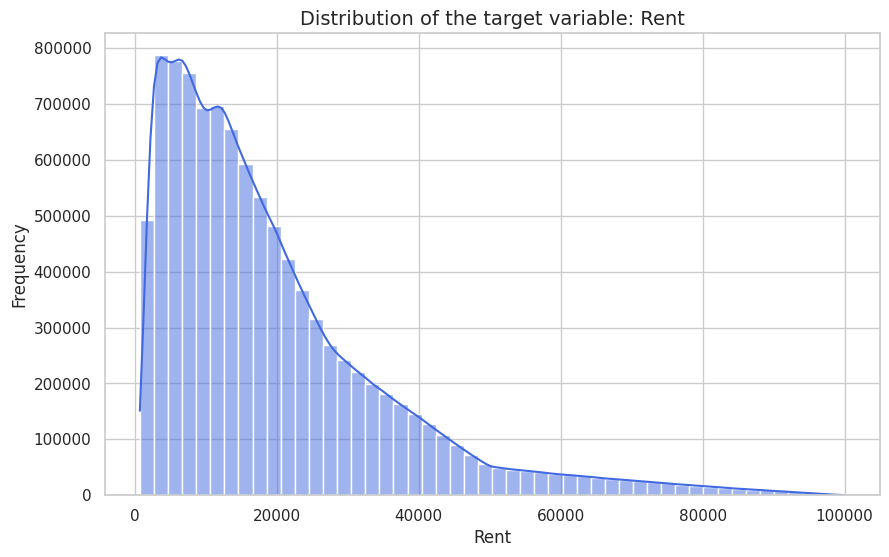

In [4]:
target_col = 'Rent' 

plt.figure(figsize=(10, 6))
sns.histplot(df[target_col], bins=50, kde=True, color='royalblue')
plt.title(f'Distribution of the target variable: {target_col}', fontsize=14)
plt.xlabel(target_col, fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Correlation matrix

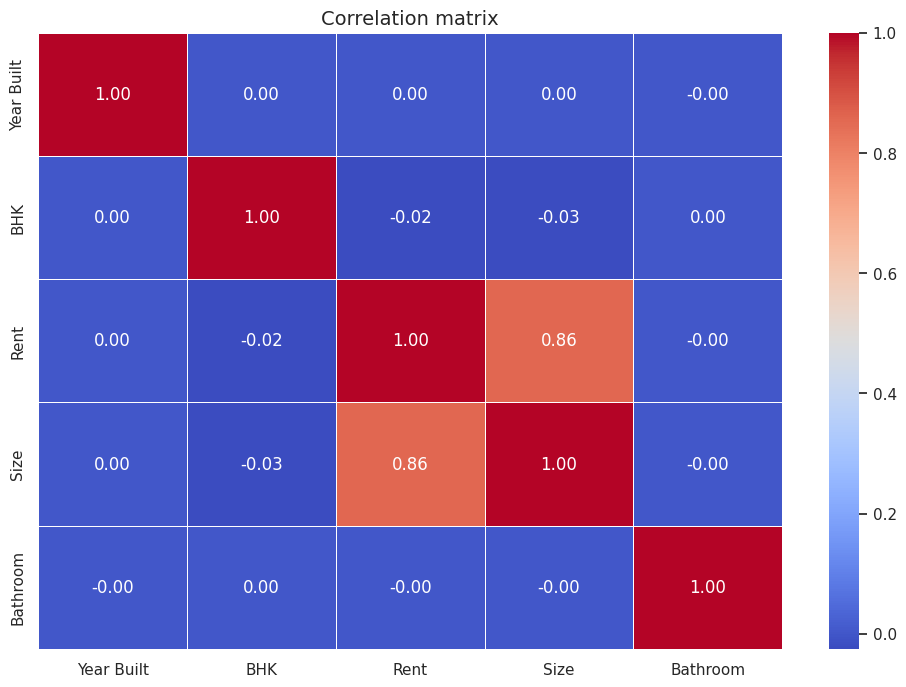

In [5]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation matrix', fontsize=14)
plt.show()

# ML Flow

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Data Loading
file_path = "/home/yura/PolProjects/mlops_labs/mlops_lab_1/data/raw/House_Rent_10M_balanced_40cities.csv"
df = pd.read_csv(file_path)

target_col = 'Rent'

# 2. Data Preprocessing

# Separate the target variable from the features
X = df.drop(columns=[target_col])
y = df[target_col]

# Fill missing values in numerical columns with the median
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Fill missing values in categorical columns with the mode (most frequent value)
cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Encode categorical variables (One-Hot Encoding)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. MLflow Initialization

# Set the experiment name
mlflow.set_experiment("House_Rent_Prediction_Lab1")

# Model hyperparameters
params = {
    "n_estimators": 100,
    "max_depth": 10,
    "random_state": 42
}

print("Starting model training and MLflow logging...")

with mlflow.start_run(run_name="RandomForest_Baseline"):
    
    # Initialize and train the model
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate quality metrics (for regression: RMSE, MAE, R2)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Metrics: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}")
    
    # --- MLFLOW LOGGING ---
    
    # 1. Log hyperparameters
    mlflow.log_params(params)
    
    # 2. Log metrics
    mlflow.log_metrics({
        "rmse": rmse,
        "mae": mae,
        "r2_score": r2
    })
    
    # 3. Log the model itself
    mlflow.sklearn.log_model(model, "random_forest_model")
    
    # 4. Create and log a plot (Feature Importance)

    feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
    plt.title("Top 10 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    
    # Save the plot to a file
    plot_filename = "feature_importance.png"
    plt.savefig(plot_filename)
    plt.close() # Close the plot so it doesn't duplicate in the notebook output
    
    # Log the plot as an artifact
    mlflow.log_artifact(plot_filename)
    
print("Training and logging completed successfully! Check the MLflow UI.")

MemoryError: Unable to allocate 90.9 TiB for an array with shape (10000000, 10000000) and data type bool